In [3]:
# Import Required Libraries
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Load the Dataset
# ==========================================
df = pd.read_csv(R"C:\Users\Soret\Downloads\BrentOilPrices.csv")

# Display the first five rows
print(df.head())


        Date  Price
0  20-May-87  18.63
1  21-May-87  18.45
2  22-May-87  18.55
3  25-May-87  18.60
4  26-May-87  18.63


In [4]:
print(df.columns)

Index(['Date', 'Price'], dtype='str')


In [12]:
print(df.index)

DatetimeIndex(['1987-05-20', '1987-05-21', '1987-05-22', '1987-05-25',
               '1987-05-26', '1987-05-27', '1987-05-28', '1987-05-29',
               '1987-06-01', '1987-06-02',
               ...
               '2022-11-01', '2022-11-02', '2022-11-03', '2022-11-04',
               '2022-11-07', '2022-11-08', '2022-11-09', '2022-11-10',
               '2022-11-11', '2022-11-14'],
              dtype='datetime64[us]', name='Date', length=9011, freq=None)


In [5]:
df.index = pd.to_datetime(df.index)

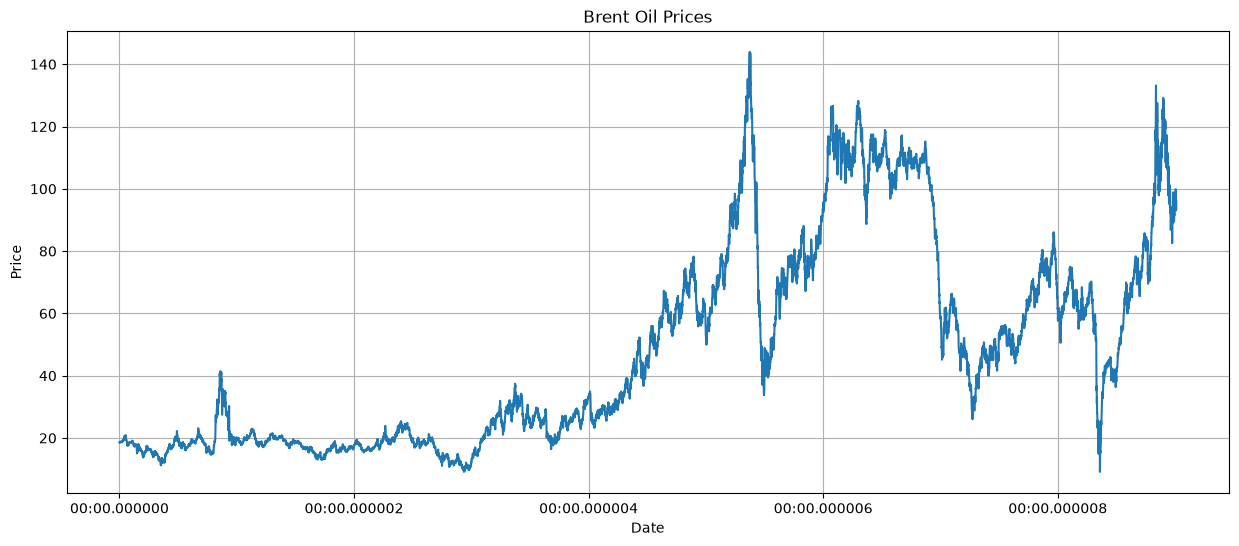

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.plot(df.index, df['Price'])
plt.title("Brent Oil Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

In [7]:
# Compute Log Returns
# Formula:
# log_return = log(P_t) - log(P_t-1)
# ==========================================
df['Log_Return'] = np.log(df['Price']) - np.log(df['Price'].shift(1))

# Remove the first missing value
df.dropna(inplace=True)

                               Price  Log_Return
1970-01-01 00:00:00.000000001  18.45   -0.009709
1970-01-01 00:00:00.000000002  18.55    0.005405
1970-01-01 00:00:00.000000003  18.60    0.002692
1970-01-01 00:00:00.000000004  18.63    0.001612
1970-01-01 00:00:00.000000005  18.60   -0.001612


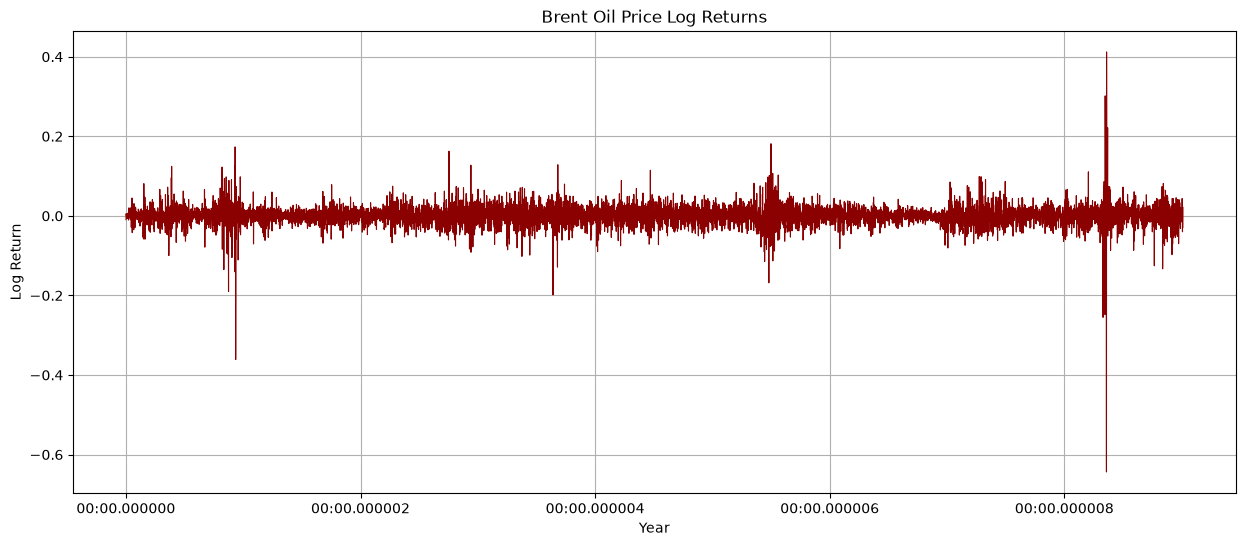

In [8]:
# Display first few log returns
print(df[['Price', 'Log_Return']].head())

# ==========================================
# Plot Log Returns
# ==========================================
plt.figure(figsize=(15,6))
plt.plot(df.index, df['Log_Return'], color='darkred', linewidth=0.8)
plt.title('Brent Oil Price Log Returns')
plt.xlabel('Year')
plt.ylabel('Log Return')
plt.grid(True)
plt.show()

In [9]:
# Summary Statistics
# ==========================================
print("\nPrice Summary Statistics")
print(df['Price'].describe())

print("\nLog Return Summary Statistics")
print(df['Log_Return'].describe())


Price Summary Statistics
count    9010.000000
mean       48.424089
std        32.860435
min         9.100000
25%        19.050000
50%        38.600000
75%        70.095000
max       143.950000
Name: Price, dtype: float64

Log Return Summary Statistics
count    9010.000000
mean        0.000179
std         0.025532
min        -0.643699
25%        -0.011154
50%         0.000402
75%         0.012127
max         0.412023
Name: Log_Return, dtype: float64


In [10]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

g++ not available, if using conda: `conda install gxx`


In [11]:
# Load dataset
df = pd.read_csv(R"C:\Users\Soret\Downloads\BrentOilPrices.csv")

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Sort by date
df = df.sort_values("Date")

# Extract prices
prices = df["Price"].values

# Time index
time = np.arange(len(prices))

C:\Users\Soret\AppData\Local\Temp\ipykernel_8208\3771211738.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


In [1]:
import sys
import numpy
import numba

print("Python executable:", sys.executable)
print("NumPy version:", numpy.__version__)
print("Numba version:", numba.__version__)

Python executable: C:\Users\Soret\Brent-Oil-Price-Analysis\venv\Scripts\python.exe
NumPy version: 2.3.3
Numba version: 0.65.1


In [12]:
with pm.Model() as change_point_model:

    # -------------------------------------------------
    # Prior for the unknown change point (tau)
    # -------------------------------------------------
    tau = pm.DiscreteUniform(
        "tau",
        lower=0,
        upper=len(prices)-1
    )

    # -------------------------------------------------
    # Priors for the means before and after the change
    # -------------------------------------------------
    mu1 = pm.Normal(
        "mu1",
        mu=np.mean(prices),
        sigma=np.std(prices)
    )

    mu2 = pm.Normal(
        "mu2",
        mu=np.mean(prices),
        sigma=np.std(prices)
    )

    # Common standard deviation
    sigma = pm.HalfNormal(
        "sigma",
        sigma=np.std(prices)
    )

    # -------------------------------------------------
    # Switch Function
    # -------------------------------------------------
    mu = pm.math.switch(
        time < tau,
        mu1,
        mu2
    )

    # -------------------------------------------------
    # Likelihood
    # -------------------------------------------------
    observation = pm.Normal(
        "observation",
        mu=mu,
        sigma=sigma,
        observed=prices
    )

    # -------------------------------------------------
    # Run MCMC Sampling
    # -------------------------------------------------
    trace = pm.sample(
        draws=2000,
        tune=1000,
        target_accept=0.95,
        random_seed=42,
        return_inferencedata=True
    )

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 51 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [13]:
az.summary(trace, var_names=["tau", "mu1", "mu2", "sigma"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau,4520.9,3.2,4500,4500,914,893,1.00,0.1,0.078
mu1,21.421,0.274,21,22,4053,2881,1.00,0.0043,0.0031
mu2,75.604,0.282,75,76,3404,2689,1.00,0.0048,0.0033
sigma,18.594,0.137,18,19,3737,2735,1.00,0.0023,0.0016


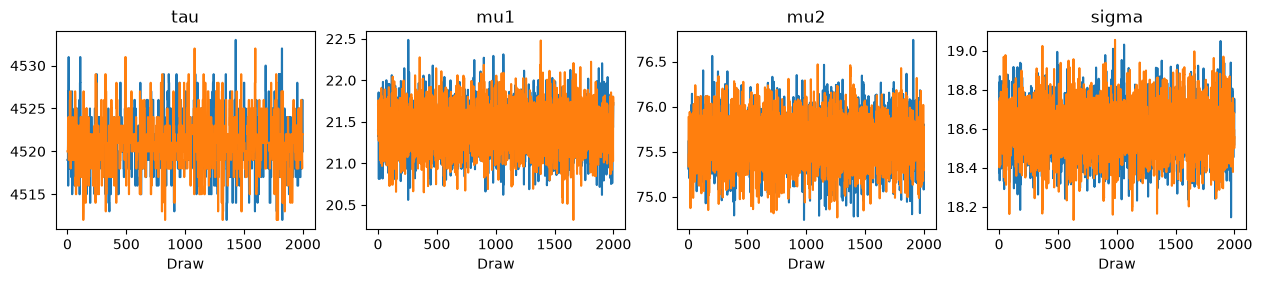

In [14]:
az.plot_trace(trace,
              var_names=["tau", "mu1", "mu2", "sigma"])

plt.show()

In [16]:
import arviz as az

print(az.__version__)

1.2.0


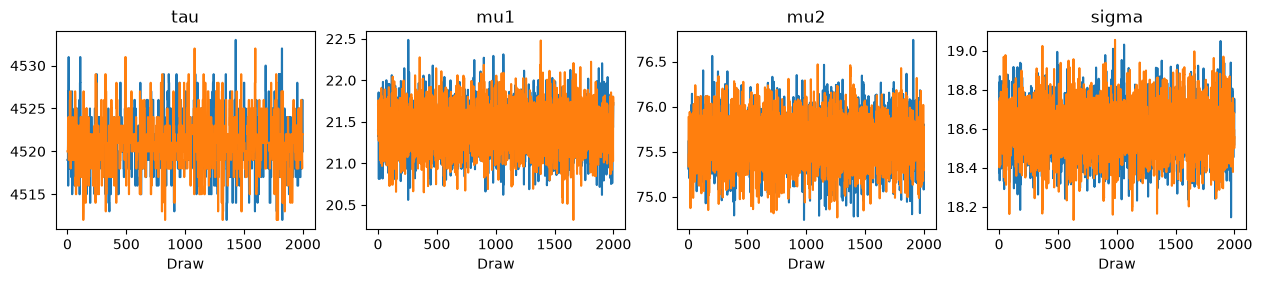

In [18]:
import arviz as az
import matplotlib.pyplot as plt

az.plot_trace(trace, var_names=["tau", "mu1", "mu2", "sigma"])
plt.show()

In [19]:
tau_estimate = int(trace.posterior["tau"].mean())

print("Estimated Change Point Index:", tau_estimate)

print("Estimated Change Date:",
      df.iloc[tau_estimate]["Date"])

Estimated Change Point Index: 4520
Estimated Change Date: 2005-02-23 00:00:00


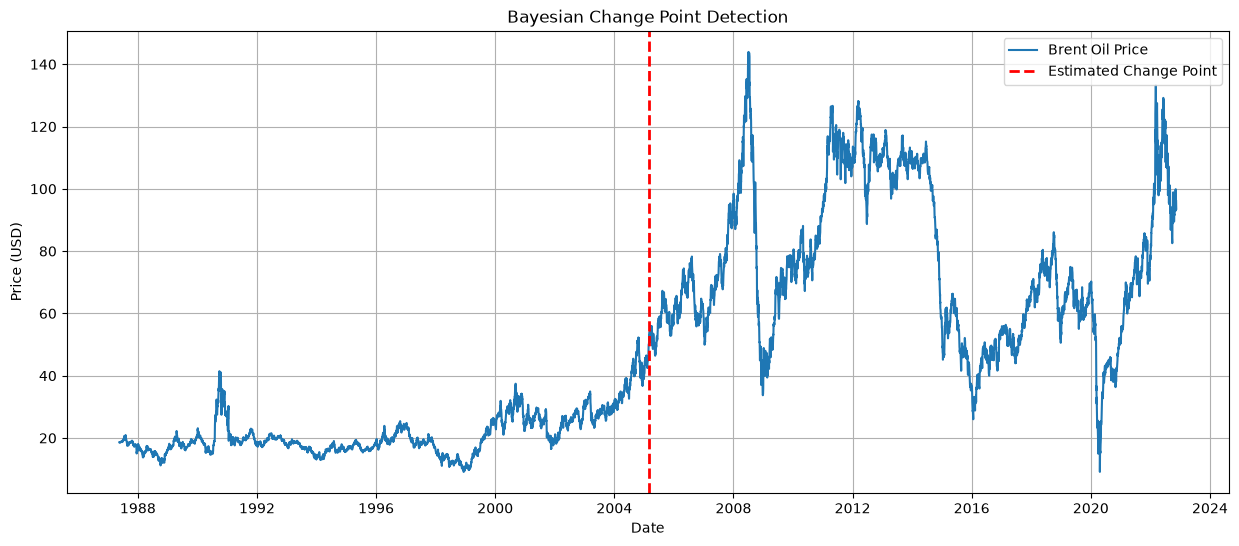

In [20]:
plt.figure(figsize=(15,6))

plt.plot(df["Date"],
         prices,
         label="Brent Oil Price")

plt.axvline(
    df.iloc[tau_estimate]["Date"],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Estimated Change Point"
)

plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.title("Bayesian Change Point Detection")
plt.legend()
plt.grid(True)

plt.show()

In [21]:
import arviz as az

summary = az.summary(trace, var_names=["tau", "mu1", "mu2", "sigma"])
print(summary)

         mean     sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean  \
tau    4520.9    3.2     4500     4500       914       893  1.00       0.1   
mu1    21.421  0.274       21       22      4053      2881  1.00    0.0043   
mu2    75.604  0.282       75       76      3404      2689  1.00    0.0048   
sigma  18.594  0.137       18       19      3737      2735  1.00    0.0023   

      mcse_sd  
tau     0.078  
mu1    0.0031  
mu2    0.0033  
sigma  0.0016  


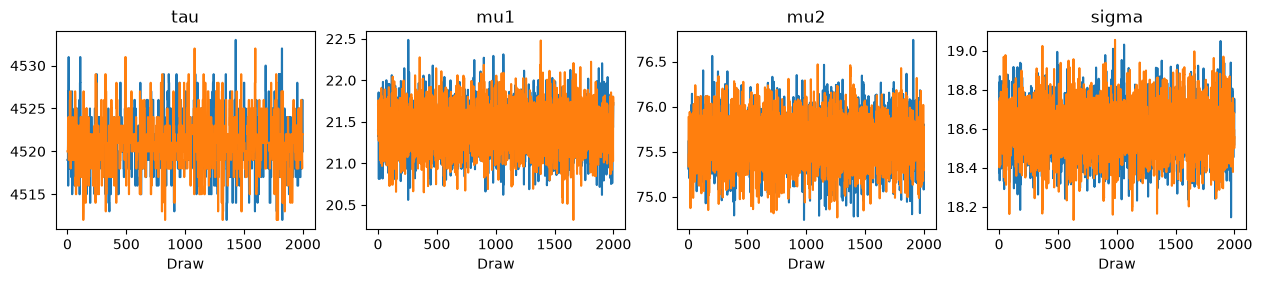

In [22]:
import matplotlib.pyplot as plt

az.plot_trace(trace, var_names=["tau", "mu1", "mu2", "sigma"])
plt.show()

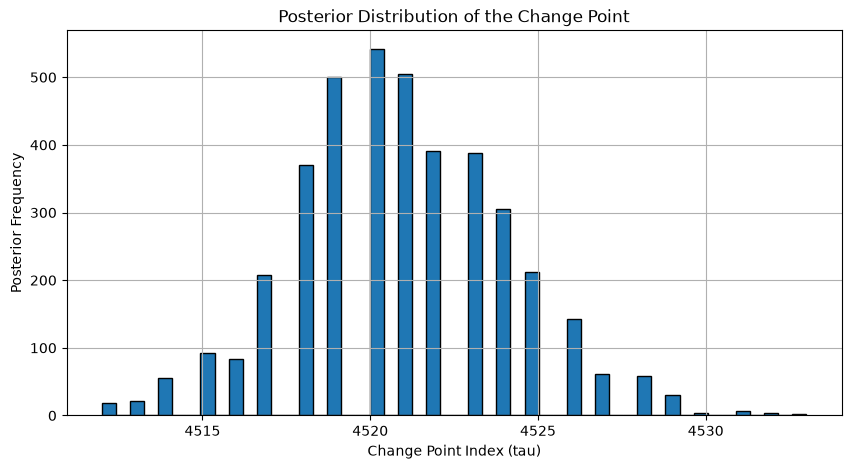

In [23]:
tau_samples = trace.posterior["tau"].values.flatten()

plt.figure(figsize=(10,5))
plt.hist(tau_samples, bins=50, edgecolor="black")
plt.xlabel("Change Point Index (tau)")
plt.ylabel("Posterior Frequency")
plt.title("Posterior Distribution of the Change Point")
plt.grid(True)
plt.show()

In [24]:
tau_estimate = int(tau_samples.mean())

print("Estimated Change Point Index:", tau_estimate)
print("Estimated Change Date:", df.iloc[tau_estimate]["Date"])

Estimated Change Point Index: 4520
Estimated Change Date: 2005-02-23 00:00:00


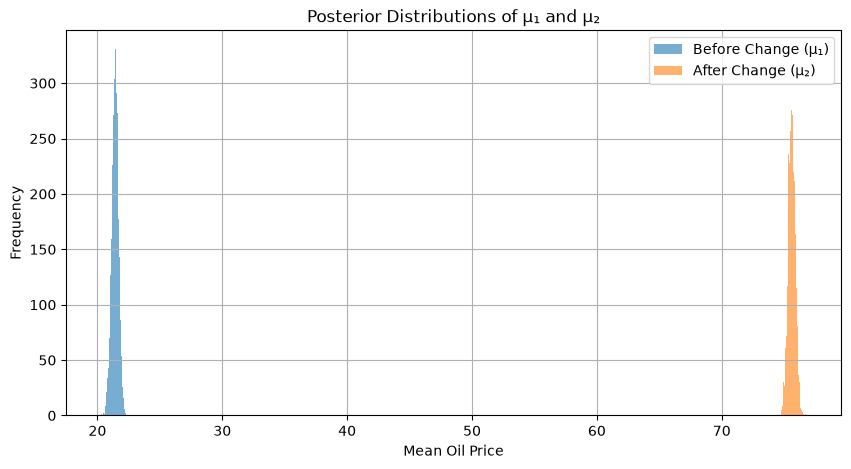

In [25]:
mu1_samples = trace.posterior["mu1"].values.flatten()
mu2_samples = trace.posterior["mu2"].values.flatten()

plt.figure(figsize=(10,5))

plt.hist(mu1_samples,
         bins=40,
         alpha=0.6,
         label="Before Change (μ₁)")

plt.hist(mu2_samples,
         bins=40,
         alpha=0.6,
         label="After Change (μ₂)")

plt.xlabel("Mean Oil Price")
plt.ylabel("Frequency")
plt.title("Posterior Distributions of μ₁ and μ₂")
plt.legend()
plt.grid(True)

plt.show()

In [26]:
import numpy as np

print(f"Posterior mean before change (μ₁): {mu1_samples.mean():.2f}")
print(f"Posterior mean after change (μ₂): {mu2_samples.mean():.2f}")

prob = np.mean(mu2_samples > mu1_samples)

print(f"P(μ₂ > μ₁) = {prob:.3f}")

Posterior mean before change (μ₁): 21.42
Posterior mean after change (μ₂): 75.60
P(μ₂ > μ₁) = 1.000


In [27]:
mu1_hdi = az.hdi(mu1_samples)
mu2_hdi = az.hdi(mu2_samples)

print("94% HDI for μ₁:", mu1_hdi)
print("94% HDI for μ₂:", mu2_hdi)

94% HDI for μ₁: [20.99058919 21.86254173]
94% HDI for μ₂: [75.1790293  76.08642903]


In [28]:
# Major events affecting Brent oil prices
events = {
    "1990-08-02": "Iraq invades Kuwait (Gulf War)",
    "1997-07-02": "Asian Financial Crisis",
    "2001-09-11": "September 11 Terrorist Attacks",
    "2003-03-20": "Iraq War Begins",
    "2008-09-15": "Global Financial Crisis (Lehman Brothers Collapse)",
    "2010-12-17": "Arab Spring",
    "2014-11-27": "OPEC Maintains Production Levels",
    "2016-11-30": "OPEC Production Cut Agreement",
    "2020-03-11": "COVID-19 Declared a Pandemic",
    "2020-04-12": "Historic OPEC+ Production Cut",
    "2022-02-24": "Russia Invades Ukraine"
}

events_df = pd.DataFrame(
    events.items(),
    columns=["Date", "Event"]
)

events_df["Date"] = pd.to_datetime(events_df["Date"])

events_df

,Date,Event
0,1990-08-02,Iraq invades Kuwait (Gulf War)
1,1997-07-02,Asian Financial Crisis
2,2001-09-11,September 11 Terrorist Attacks
3,2003-03-20,Iraq War Begins
4,2008-09-15,Global Financial Crisis (Lehman Brothers Colla...
5,2010-12-17,Arab Spring
6,2014-11-27,OPEC Maintains Production Levels
7,2016-11-30,OPEC Production Cut Agreement
8,2020-03-11,COVID-19 Declared a Pandemic
9,2020-04-12,Historic OPEC+ Production Cut


In [29]:
# Estimated change point from the Bayesian model
change_date = df.iloc[tau_estimate]["Date"]

print("Estimated Change Point:", change_date)

# Compute the time difference
events_df["Difference (Days)"] = (
    abs(events_df["Date"] - change_date)
).dt.days

nearest_event = events_df.sort_values("Difference (Days)").iloc[0]

print(nearest_event)

Estimated Change Point: 2005-02-23 00:00:00
Date                 2003-03-20 00:00:00
Event                    Iraq War Begins
Difference (Days)                    706
Name: 3, dtype: object


In [30]:
before_prices = df.iloc[:tau_estimate]["Price"]
after_prices = df.iloc[tau_estimate:]["Price"]

before_mean = before_prices.mean()
after_mean = after_prices.mean()

percent_change = (
    (after_mean - before_mean) / before_mean
) * 100

print(f"Average price before change: ${before_mean:.2f}")
print(f"Average price after change : ${after_mean:.2f}")
print(f"Percentage change          : {percent_change:.2f}%")

Average price before change: $21.41
Average price after change : $75.60
Percentage change          : 253.06%
